In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [112]:
train = pd.read_csv("data/train.txt", sep=" ", header=None)
train.head()

,0,1,2
0,939,3809,1
1,2442,5784,1
2,179,3809,1
3,857,2280,1
4,1358,5722,1


In [113]:
train.columns = ["source", "target", "label"]
train.head()

,source,target,label
0,939,3809,1
1,2442,5784,1
2,179,3809,1
3,857,2280,1
4,1358,5722,1


In [114]:
#at least temporarily, for the purpose of analysis, we choose to ignore self loops  

train = train[train["source"] != train["target"]]

In [115]:
#we reconstruct the graph using only the edges labeled 1 

G = nx.Graph()
edges = train[train["label"] == 1][["source", "target"]].values
G.add_edges_from(edges)

In [116]:
node_info = pd.read_csv("data/node_information.csv", header=None)

In [117]:
node_info.shape

(3597, 933)

In [118]:
node_info.head()

,0,1,2,3,4,5,6,7,8,9,...,923,924,925,926,927,928,929,930,931,932
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [119]:
node_info = node_info.rename(columns={0: "node"})
node_info = node_info.set_index("node")
node_info.head()

,1,2,3,4,5,6,7,8,9,10,...,923,924,925,926,927,928,929,930,931,932
node,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
features = node_info.copy()
non_zero_counts = (features != 0).sum(axis=1)
counts = non_zero_counts.value_counts().sort_index()

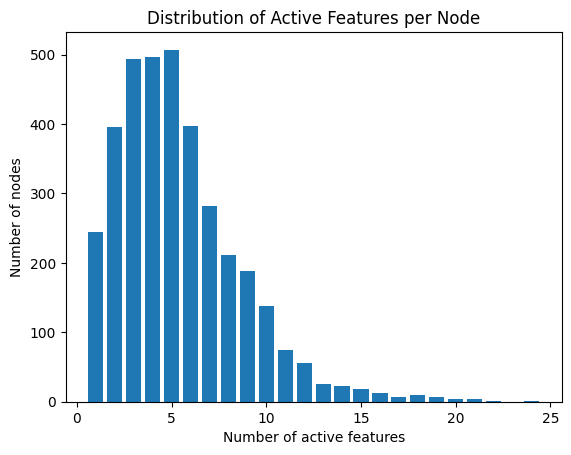

In [121]:
plt.bar(counts.index, counts.values)
plt.xlabel("Number of active features")
plt.ylabel("Number of nodes")
plt.title("Distribution of Active Features per Node")
plt.show()

In [122]:
all_zero_nodes = (features == 0).all(axis=1)
all_zero_nodes.sum() #as expected, there is no node without an active feature 

0

In [123]:
feature_freq = (features != 0).sum(axis=0)
freq_counts = feature_freq.value_counts().sort_index()

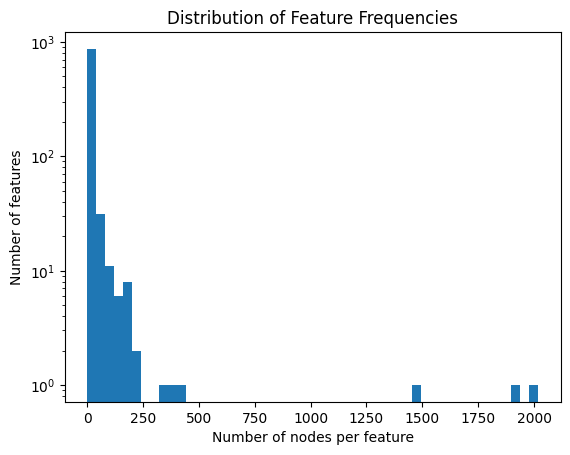

In [124]:
plt.hist(feature_freq, bins=50) 
plt.xlabel("Number of nodes per feature")
plt.ylabel("Number of features")
plt.yscale("log") 
plt.title("Distribution of Feature Frequencies")
plt.show()

In [125]:
(feature_freq == 0).sum() #3 features are not active for any node and are therefore useless 

3

In [126]:
non_zero_features = feature_freq[feature_freq > 0].index #from now on we will ignore them 
features = features[non_zero_features]
feature_freq = (features != 0).sum(axis=0)

In [127]:
(feature_freq == len(features)).sum() #fortunately, there are not any features that are always active

0

In [157]:
feature_freq.value_counts()

3     114
5     108
4     107
2      69
6      67
     ... 
37      1
55      1
98      1
94      1
82      1
Name: count, Length: 89, dtype: int64

In [129]:
rare_features = (feature_freq <= 2).sum()
print("Number of very rare features:", rare_features)
print("Max frequency:", feature_freq.max())
print("Median frequency:", feature_freq.median()) 

#the distribution of the active features is really very unbalanced

Number of very rare features: 97
Max frequency: 2018
Median frequency: 6.0


In [130]:
def compute_overlap(u, v):
    return ((features.loc[u] != 0) & (features.loc[v] != 0)).sum()

In [131]:
overlaps = []

for _, row in train.iterrows():
    u = row["source"]
    v = row["target"]
    overlaps.append(compute_overlap(u, v))

In [132]:
overlaps = np.array(overlaps)
labels = train["label"].values

overlap_pos = overlaps[labels == 1]
overlap_neg = overlaps[labels == 0]

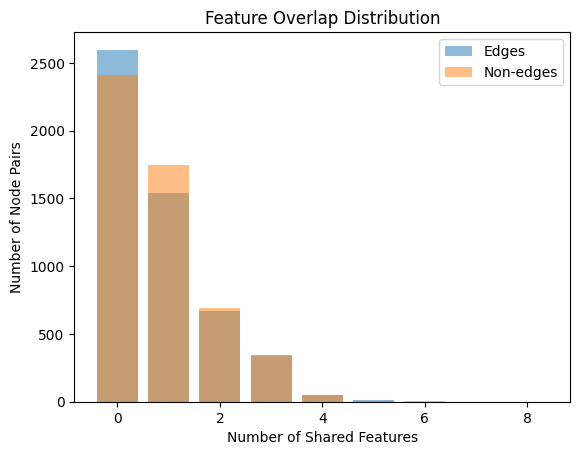

In [133]:
pos_counts = pd.Series(overlap_pos).value_counts().sort_index()
neg_counts = pd.Series(overlap_neg).value_counts().sort_index()

plt.bar(pos_counts.index, pos_counts.values, alpha=0.5, label="Edges")
plt.bar(neg_counts.index, neg_counts.values, alpha=0.5, label="Non-edges")
plt.xlabel("Number of Shared Features")
plt.ylabel("Number of Node Pairs")
plt.title("Feature Overlap Distribution")
plt.legend()
plt.show()

In [ ]:
#most node pairs do not share any features, regardless of whether an edge exists
#so direct feature similarity is not a reliable signal

In [ ]:
#we evaluate anyway a range of similarity and distance measures to confirm whether more global comparisons 
#could capture meaningful relationships

In [ ]:
#cosine similarity 

In [158]:
def cosine_sim(u, v):
    if u not in features.index or v not in features.index:
        return 0.0
    
    f_u = features.loc[u].values
    f_v = features.loc[v].values

    norm_u = np.linalg.norm(f_u)
    norm_v = np.linalg.norm(f_v)

    if norm_u == 0 or norm_v == 0:
        return 0.0

    return np.dot(f_u, f_v) / (norm_u * norm_v)

In [159]:
cosines = []

for _, row in train.iterrows():
    u = row["source"]
    v = row["target"]
    cosines.append(cosine_sim(u, v))

cosines = np.array(cosines)
labels = train["label"].values

In [160]:
cos_pos = cosines[labels == 1]
cos_neg = cosines[labels == 0]

print("Mean cosine edges:", cos_pos.mean())
print("Mean cosine non-edges:", cos_neg.mean())

Mean cosine edges: 0.15379134471050468
Mean cosine non-edges: 0.16162035505984


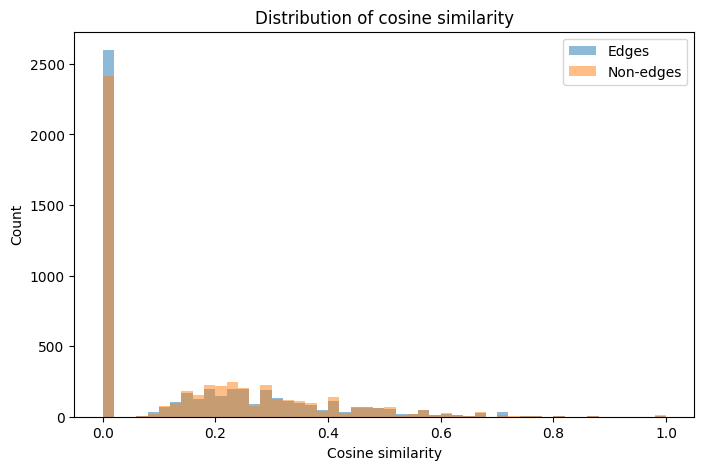

In [163]:
plt.figure(figsize=(8,5))
plt.hist(cos_pos, bins=50, alpha=0.5, label="Edges")
plt.hist(cos_neg, bins=50, alpha=0.5, label="Non-edges")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Distribution of cosine similarity")
plt.legend()
plt.show()

In [ ]:
#cosine similarity is mostly zero and does not separate edges from non-edges, this feature is too sparse 
#to be useful on its own

In [ ]:
#Jaccard text 

In [164]:
def jaccard_text(u, v):
    if u not in features.index or v not in features.index:
        return 0
    
    f_u = features.loc[u] != 0
    f_v = features.loc[v] != 0
    
    inter = (f_u & f_v).sum()
    union = (f_u | f_v).sum()
    
    return inter / union if union > 0 else 0

In [169]:
jaccards = []

for _, row in train.iterrows():
    u = row["source"]
    v = row["target"]
    jaccards.append(jaccard_text(u, v))

jaccards = np.array(jaccards)
labels = train["label"].values

In [170]:
jac_pos = jaccards[labels == 1]
jac_neg = jaccards[labels == 0]

print("Mean Jaccard edges:", jac_pos.mean())
print("Mean Jaccard non-edges:", jac_neg.mean())

Mean Jaccard edges: 0.0893015369151183
Mean Jaccard non-edges: 0.0930849037124534


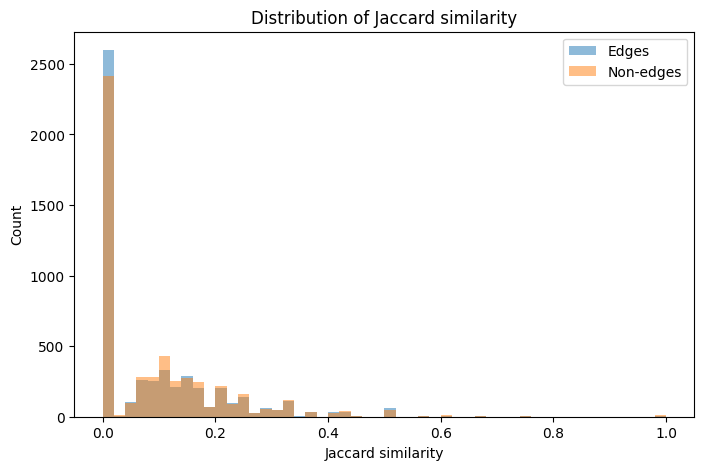

In [172]:
plt.figure(figsize=(8,5))
plt.hist(jac_pos, bins=50, alpha=0.5, label="Edges")
plt.hist(jac_neg, bins=50, alpha=0.5, label="Non-edges")
plt.xlabel("Jaccard similarity")
plt.ylabel("Count")
plt.title("Distribution of Jaccard similarity")
plt.legend()
plt.show()

In [ ]:
#Jaccard text similarity is mostly zero and does not separate edges from non-edges, this feature is too 
#sparse to be useful on its own

In [ ]:
#L1 distance 

In [165]:
def l1_distance(u, v):
    f_u = features.loc[u].values
    f_v = features.loc[v].values
    return np.sum(np.abs(f_u - f_v))

In [173]:
l1_vals = []

for _, row in train.iterrows():
    u = row["source"]
    v = row["target"]
    l1_vals.append(l1_distance(u, v))

l1_vals = np.array(l1_vals)
labels = train["label"].values

In [174]:
l1_pos = l1_vals[labels == 1]
l1_neg = l1_vals[labels == 0]

print("Mean L1 edges:", l1_pos.mean())
print("Mean L1 non-edges:", l1_neg.mean())

Mean L1 edges: 9.25531914893617
Mean L1 non-edges: 9.089367378048781


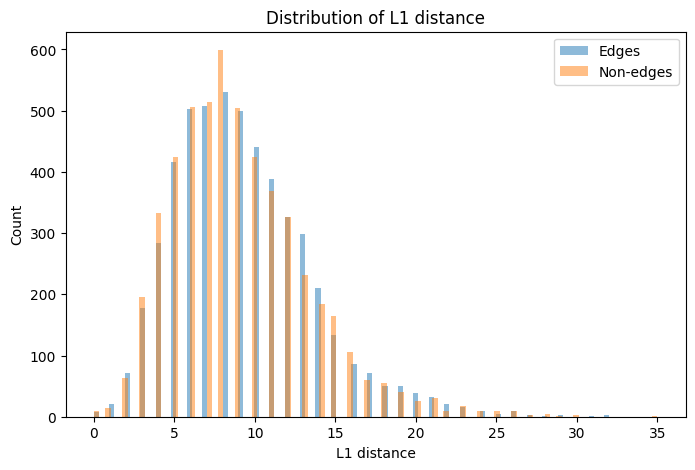

In [182]:
plt.figure(figsize=(8,5))
plt.hist(l1_pos, bins=100, alpha=0.5, label="Edges")
plt.hist(l1_neg, bins=100, alpha=0.5, label="Non-edges")
plt.xlabel("L1 distance")
plt.ylabel("Count")
plt.title("Distribution of L1 distance")
plt.legend()
plt.show()

In [ ]:
#again, the distributions are highly overlapping

In [ ]:
#L2 distance 

In [166]:
def l2_distance(u, v):
    f_u = features.loc[u].values
    f_v = features.loc[v].values
    return np.linalg.norm(f_u - f_v)

In [183]:
l2_vals = []

for _, row in train.iterrows():
    u = row["source"]
    v = row["target"]
    l2_vals.append(l2_distance(u, v))

l2_vals = np.array(l2_vals)
labels = train["label"].values

In [188]:
l2_pos = l2_vals[labels == 1]
l2_neg = l2_vals[labels == 0]

print("Mean L2 edges:", l2_pos.mean())
print("Mean L2 non-edges:", l2_neg.mean())

Mean L2 edges: 2.9596561926353364
Mean L2 non-edges: 2.9322837664542556


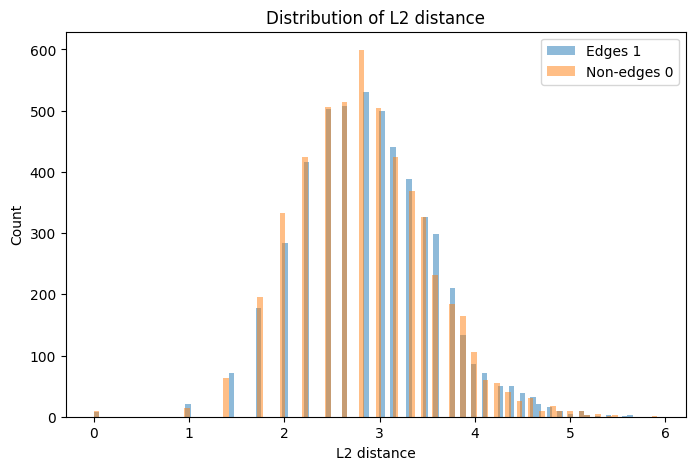

In [186]:
plt.figure(figsize=(8,5))
plt.hist(l2_pos, bins=100, alpha=0.5, label="Edges 1")
plt.hist(l2_neg, bins=100, alpha=0.5, label="Non-edges 0")
plt.xlabel("L2 distance")
plt.ylabel("Count")
plt.title("Distribution of L2 distance")
plt.legend()
plt.show()

In [ ]:
#again, the distributions are highly overlapping

In [ ]:
#dot product 

In [189]:
def dot_product(u, v):
    f_u = features.loc[u].values
    f_v = features.loc[v].values
    return np.dot(f_u, f_v)

In [190]:
dot_vals = []

for _, row in train.iterrows():
    u = row["source"]
    v = row["target"]
    dot_vals.append(dot_product(u, v))

dot_vals = np.array(dot_vals)
labels = train["label"].values

In [191]:
dot_pos = dot_vals[labels == 1]
dot_neg = dot_vals[labels == 0]

print("Mean dot product edges:", dot_pos.mean())
print("Mean dot product non-edges:", dot_neg.mean())

Mean dot product edges: 0.8021851638872916
Mean dot product non-edges: 0.8366996951219512


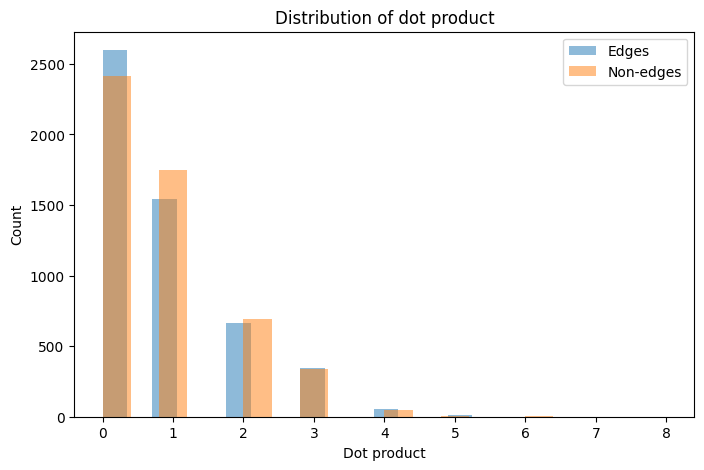

In [193]:
plt.figure(figsize=(8,5))
plt.hist(dot_pos, bins=20, alpha=0.5, label="Edges")
plt.hist(dot_neg, bins=20, alpha=0.5, label="Non-edges")
plt.xlabel("Dot product")
plt.ylabel("Count")
plt.title("Distribution of dot product")
plt.legend()
plt.show()

In [ ]:
#as expected, the dot product does not provide meaningful separation between edges and non-edges due to 
#the high sparsity of the node features

In [ ]:
#as expected, all tested classic measures exhibit very very limited discriminative power
#so we are going to try some new approaches 

In [ ]:
#let us see if the richness of an actor’s textual profile has any influence

In [214]:
feat_count = (features != 0).sum(axis=1)

In [215]:
train["feat_u"] = train["source"].map(feat_count)
train["feat_v"] = train["target"].map(feat_count)

In [216]:
train["feat_sum"] = train["feat_u"] + train["feat_v"]
train["feat_diff"] = abs(train["feat_u"] - train["feat_v"])
train["feat_prod"] = train["feat_u"] * train["feat_v"]
train["feat_max"] = train[["feat_u", "feat_v"]].max(axis=1)
train["feat_min"] = train[["feat_u", "feat_v"]].min(axis=1)

In [217]:
train.groupby("label")["feat_sum"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,5248.0,10.762767,4.576222,2.0,8.0,10.0,13.0,37.0
1,5217.0,10.859689,4.562309,2.0,8.0,10.0,13.0,36.0


In [218]:
train.groupby("label")["feat_diff"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,5248.0,3.479992,3.012075,0.0,1.0,3.0,5.0,22.0
1,5217.0,3.446617,2.943466,0.0,1.0,3.0,5.0,20.0


In [219]:
train.groupby("label")["feat_prod"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,5248.0,28.898438,27.088364,1.0,12.0,21.0,36.0,312.0
1,5217.0,29.550508,27.192448,1.0,12.0,21.0,40.0,288.0


In [220]:
train.groupby("label")["feat_max"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,5248.0,7.121380,3.309051,1.0,5.0,7.0,9.0,24.0
1,5217.0,7.153153,3.257207,1.0,5.0,7.0,9.0,24.0


In [221]:
train.groupby("label")["feat_min"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,5248.0,3.641387,2.014295,1.0,2.0,3.0,5.0,16.0
1,5217.0,3.706536,2.032223,1.0,2.0,3.0,5.0,16.0


In [ ]:
#node-level statistics do not exhibit any discriminative power, so the richness of an actor’s textual 
#profile is not informative for link prediction

In [ ]:
#let us now consider the rarity of features, taking into account the overlap and the fact that not all 
#features have the same frequency

In [222]:
feature_weight = 1 / np.log(1 + feature_freq)

In [223]:
def weighted_overlap(u, v):
    if u not in features.index or v not in features.index:
        return 0.0
    
    f_u = features.loc[u] != 0
    f_v = features.loc[v] != 0
    
    common = f_u & f_v
    
    if common.sum() == 0:
        return 0.0
    
    return feature_weight[common].sum()

In [224]:
w_overlap = []

for _, row in train.iterrows():
    u = row["source"]
    v = row["target"]
    w_overlap.append(weighted_overlap(u, v))

w_overlap = np.array(w_overlap)
labels = train["label"].values

In [225]:
w_pos = w_overlap[labels == 1]
w_neg = w_overlap[labels == 0]

print("Mean weighted overlap edges:", w_pos.mean())
print("Mean weighted overlap non-edges:", w_neg.mean())

Mean weighted overlap edges: 0.1139881011564449
Mean weighted overlap non-edges: 0.11744486563344685


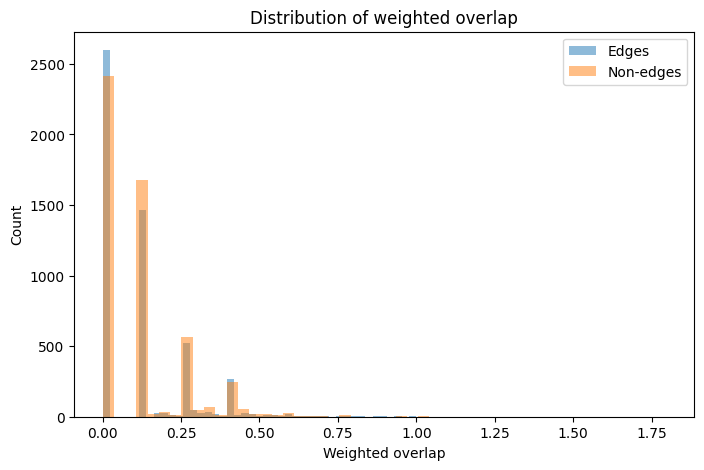

In [228]:
plt.figure(figsize=(8,5))
plt.hist(w_pos, bins=50, alpha=0.5, label="Edges")
plt.hist(w_neg, bins=50, alpha=0.5, label="Non-edges")
plt.xlabel("Weighted overlap")
plt.ylabel("Count")
plt.title("Distribution of weighted overlap")
plt.legend()
plt.show()

In [ ]:
#the distributions for positive and negative edges remained highly overlapping

In [ ]:
#let us now look at the interactions between node features and graph properties 

In [229]:
node_degree = dict(G.degree())

In [230]:
feature_degree = {}

for f in features.columns:
    nodes_with_f = features[features[f] != 0].index
    
    degrees = [node_degree.get(u, 0) for u in nodes_with_f]
    
    if len(degrees) > 0:
        feature_degree[f] = np.mean(degrees)

In [231]:
df_feat = pd.Series(feature_degree)
df_feat.sort_values(ascending=False).head(10)

278    62.500000
276    55.142857
259    34.818182
347    24.500000
354    19.500000
524    19.000000
318    18.000000
539    17.000000
268    16.680000
460    16.000000
dtype: float64

In [232]:
feature_counts = (features != 0).sum(axis=0)

df_feat = pd.DataFrame({
    "mean_degree": pd.Series(feature_degree),
    "count": feature_counts
})

df_feat.sort_values("mean_degree", ascending=False).head(10)

,mean_degree,count
278,62.500000,6
276,55.142857,7
259,34.818182,11
347,24.500000,2
354,19.500000,2
524,19.000000,2
318,18.000000,2
539,17.000000,2
268,16.680000,25
460,16.000000,1


In [ ]:
#features 278, 276, 259 and 268 are associated with highly connected nodes

In [233]:
feature_sets = {
    u: set(features.loc[u][features.loc[u] != 0].index)
    for u in features.index
}

In [234]:
def neighbor_feature_overlap(u, v):
    neighbors_v = list(G.neighbors(v))
    
    if len(neighbors_v) == 0:
        return 0
    
    Fu = feature_sets[u]
    
    count = 0
    for n in neighbors_v:
        count += len(Fu & feature_sets[n])
    
    return count

In [235]:
scores = []

for u, v in train[["source", "target"]].values:
    scores.append(neighbor_feature_overlap(u, v))

In [236]:
scores = np.array(scores)
labels = train["label"].values

In [237]:
print("Mean score for edges:", scores[labels == 1].mean())
print("Mean score for non-edges:", scores[labels == 0].mean())

Mean score for edges: 33.7906843013226
Mean score for non-edges: 2.442454268292683


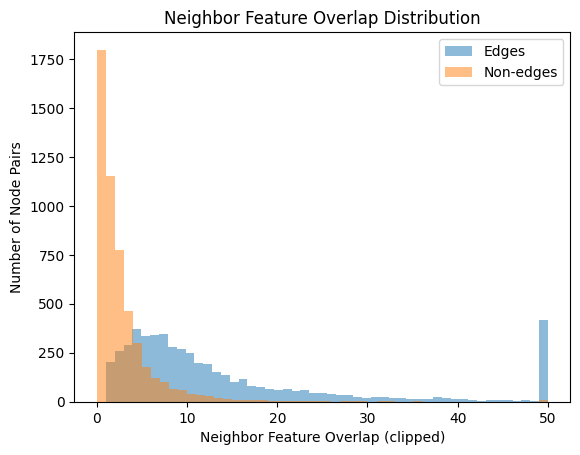

In [238]:
scores_clipped = np.clip(scores, 0, 50)

plt.hist(scores_clipped[labels == 1], bins=50, alpha=0.5, label="Edges")
plt.hist(scores_clipped[labels == 0], bins=50, alpha=0.5, label="Non-edges")

plt.xlabel("Neighbor Feature Overlap (clipped)")
plt.ylabel("Number of Node Pairs")
plt.title("Neighbor Feature Overlap Distribution")
plt.legend()

plt.show()

In [239]:
print("Min:", scores.min())
print("Max:", scores.max())
print("Mean:", scores.mean())

Min: 0
Max: 695
Mean: 18.070138557095078


In [240]:
print("Median edges:", np.median(scores[labels == 1]))
print("Median non-edges:", np.median(scores[labels == 0]))

Median edges: 9.0
Median non-edges: 1.0


In [ ]:
#score = the number of features of node u present in the neighbors of node v
#it is basically a measure of whether actor u resembles the actors to which v is linked 

In [ ]:
#NFO is asymmetric and depends on node ordering, and since node pairs are unordered, we have to include 
#both NFO(u,v) and NFO(v,u) to capture complementary information

In [259]:
sym_scores = []

for u, v in train[["source", "target"]].values:
    score_uv = neighbor_feature_overlap(u, v)
    score_vu = neighbor_feature_overlap(v, u)
    
    sym_scores.append(score_uv + score_vu)

sym_scores = np.array(sym_scores)
labels = train["label"].values

In [260]:
sym_pos = sym_scores[labels == 1]
sym_neg = sym_scores[labels == 0]

print("Mean sym score edges:", sym_pos.mean())
print("Mean sym score non-edges:", sym_neg.mean())

Mean sym score edges: 42.65382403680276
Mean sym score non-edges: 4.498094512195122


In [ ]:
#we also have to mitigate the bias introduced by high-degree nodes : without normalization, nodes with 
#many neighbors tend to have higher scores regardless of actual similarity ;  dividing by the number of 
#neighbors removes this bias

In [261]:
def neighbor_feature_overlap_norm(u, v):
    neighbors_v = list(G.neighbors(v))
    
    if len(neighbors_v) == 0:
        return 0.0
    
    Fu = feature_sets[u]
    
    count = 0
    for n in neighbors_v:
        count += len(Fu & feature_sets[n])
    
    return count / len(neighbors_v)

In [262]:
sym_scores_norm = []

for u, v in train[["source", "target"]].values:
    score_uv = neighbor_feature_overlap_norm(u, v)
    score_vu = neighbor_feature_overlap_norm(v, u)
    
    sym_scores_norm.append(score_uv + score_vu)

sym_scores_norm = np.array(sym_scores_norm)
labels = train["label"].values

In [263]:
sym_pos = sym_scores_norm[labels == 1]
sym_neg = sym_scores_norm[labels == 0]

print("Mean normalized sym score edges:", sym_pos.mean())
print("Mean normalized sym score non-edges:", sym_neg.mean())

Mean normalized sym score edges: 4.891955358360658
Mean normalized sym score non-edges: 1.5556409083044893


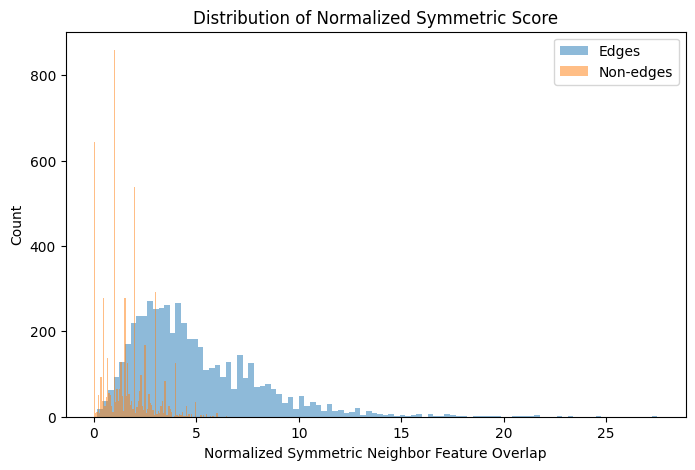

In [269]:
plt.figure(figsize=(8,5))
plt.hist(sym_pos, bins=100, alpha=0.5, label="Edges")
plt.hist(sym_neg, bins=100, alpha=0.5, label="Non-edges")
plt.xlabel("Normalized Symmetric Neighbor Feature Overlap")
plt.ylabel("Count")
plt.title("Distribution of Normalized Symmetric Score")
plt.legend()
plt.show()

In [ ]:
#so the symmetric and normalized NFO score does seem to capture a signal ! 

In [283]:
def common_neighbors(u, v):
    return len(list(nx.common_neighbors(G, u, v)))

In [284]:
cn_list = []

for u, v in train[["source", "target"]].values:
    cn = common_neighbors(u, v)
    cn_list.append(cn)

cn_array = np.array(cn_list)

In [285]:
df_analysis = pd.DataFrame({"nf": scores, "cn": cn_array, "label": labels})

In [286]:
for k in [0, 1, 2]:
    subset = df_analysis[df_analysis["cn"] == k]
    
    print(f"\n=== CN = {k} ===")
    print("Count:", len(subset))
    
    if len(subset) > 0:
        print("Edges:", (subset["label"] == 1).sum())
        print("Non-edges:", (subset["label"] == 0).sum())
        print("Edge ratio:", (subset["label"] == 1).mean())
        print("Edges:", subset[subset["label"] == 1]["nf"].mean())
        print("Non-edges:", subset[subset["label"] == 0]["nf"].mean())


=== CN = 0 ===
Count: 9886
Edges: 4712
Non-edges: 5174
Edge ratio: 0.4766336233056848
Edges: 34.43081494057725
Non-edges: 2.4451101662156938

=== CN = 1 ===
Count: 510
Edges: 436
Non-edges: 74
Edge ratio: 0.8549019607843137
Edges: 26.357798165137616
Non-edges: 2.2567567567567566

=== CN = 2 ===
Count: 58
Edges: 58
Non-edges: 0
Edge ratio: 1.0
Edges: 39.672413793103445
Non-edges: nan


In [ ]:
#for CN = 0, which represents the vast majority of node pairs, the dataset is approximately balanced 
#between edges and non-edges and neighbor feature overlap shows a discriminative power ! 

In [287]:
df_cn0 = df_analysis[df_analysis["cn"] == 0].copy()

In [288]:
df_grouped = df_cn0.groupby("nf")["label"].mean()

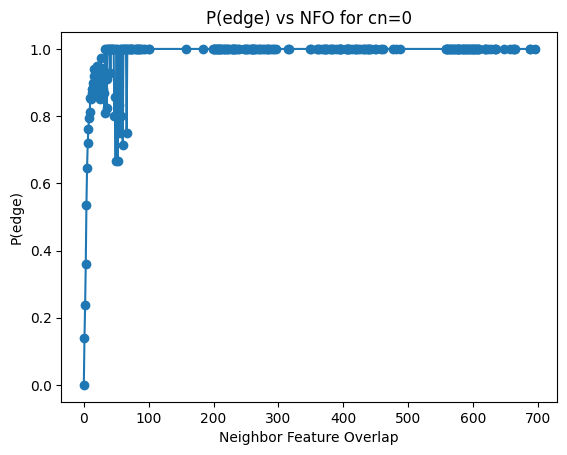

In [289]:
plt.plot(df_grouped.index, df_grouped.values, marker='o')
plt.xlabel("Neighbor Feature Overlap")
plt.ylabel("P(edge)")
plt.title("P(edge) vs NFO for cn=0")
plt.show()

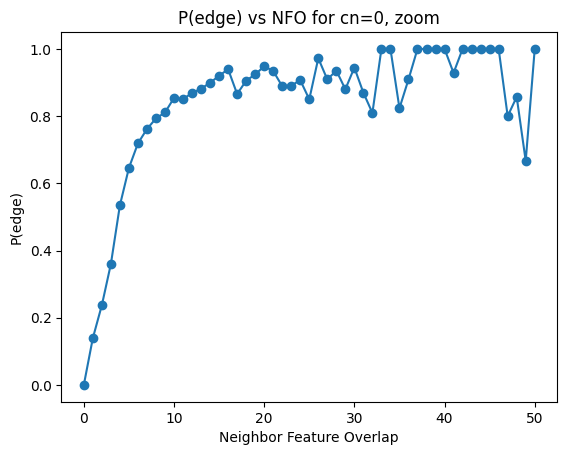

In [290]:
mask = df_grouped.index <= 50

plt.plot(df_grouped.index[mask], df_grouped.values[mask], marker='o')
plt.xlabel("Neighbor Feature Overlap")
plt.ylabel("P(edge)")
plt.title("P(edge) vs NFO for cn=0, zoom")
plt.show()

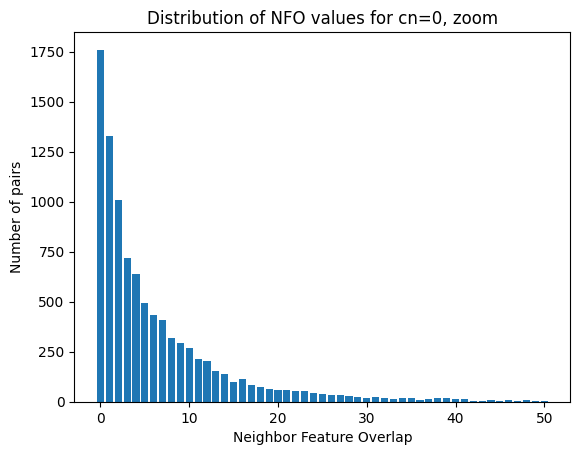

In [291]:
counts = df_cn0["nf"].value_counts().sort_index()
mask = counts.index <= 50

plt.bar(counts.index[mask], counts.values[mask])
plt.xlabel("Neighbor Feature Overlap")
plt.ylabel("Number of pairs")
plt.title("Distribution of NFO values for cn=0, zoom")
plt.show()

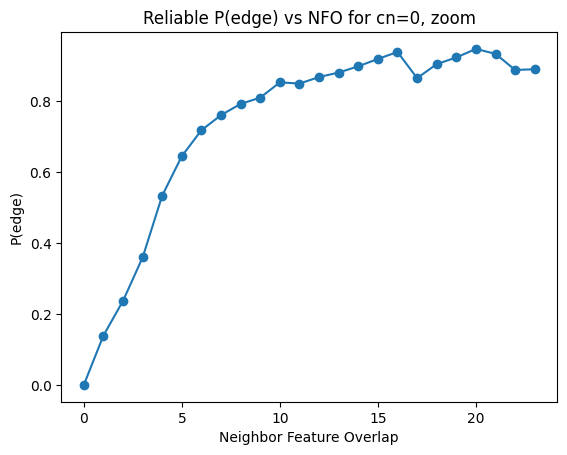

In [303]:
counts_label = df_cn0.groupby(["nf", "label"]).size().unstack(fill_value=0)
counts_label["total"] = counts_label.sum(axis=1)
counts_label["edge_ratio"] = counts_label[1] / counts_label["total"]
reliable = counts_label[counts_label["total"] >= 50] #we discard values for which there is insufficient data

plt.plot(reliable.index, reliable["edge_ratio"], marker='o')
plt.xlabel("Neighbor Feature Overlap")
plt.ylabel("P(edge)")
plt.title("Reliable P(edge) vs NFO for cn=0, zoom")
plt.show()

In [ ]:
#let us also consider the interactions between node features and features derived from the graph structure 

In [307]:
cosine_list = []

for u, v in train[["source", "target"]].values:
    cosine_list.append(cosine_sim(u, v))

train["cosine"] = cosine_list

In [308]:
train["cn_x_cosine"] = train["cn"] * train["cosine"]

In [310]:
train.groupby("label")[["cosine", "cn_x_cosine"]].describe()

cosine                                                         \
        count      mean       std  min  25%       50%       75%  max   
label                                                                  
0      5248.0  0.161620  0.183079  0.0  0.0  0.141421  0.282843  1.0   
1      5217.0  0.153791  0.186486  0.0  0.0  0.083333  0.267261  1.0   

      cn_x_cosine                                                    
            count      mean       std  min  25%  50%  75%       max  
label                                                                
0          5248.0  0.002351  0.030807  0.0  0.0  0.0  0.0  0.774597  
1          5217.0  0.017275  0.096247  0.0  0.0  0.0  0.0  2.449490

In [311]:
df_cn_pos = train[train["cn"] > 0]
df_cn_pos.groupby("label")["cn_x_cosine"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,74.0,0.166764,0.201048,0.0,0.0,0.125469,0.279500,0.774597
1,505.0,0.178459,0.258936,0.0,0.0,0.000000,0.298142,2.449490


In [ ]:
#sosine similarity alone does not provide useful information, however its interaction with structural 
#features does 